# YS vs Allantois T and Eomes ChIP comparison

In [1]:
here::i_am("revisions/04_TEomes_interaction/01_YSAllantoisTrajectory.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(BiocParallel))

suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM
set.seed(42)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [3]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# Trajectory analysis dir 
args$TrajDir = file.path(io$basedir, 'results/rna_atac/trajectory/v3')

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/04_TEomes_interaction/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [10]:
# Load meta
meta = fread(args$metadata)[day %in% c('D3', 'D3.5', 'D4', 'D4.5', 'D5')] %>% 
    .[celltype_v2 %in% c('Primitive_Streak', 'Early_Mes_EOi','Early_Mes_EOd','Posterior_Mes','HE_Precursor', 'HE', 'Allantois_Precursor')]

In [13]:
rna.sce = readRDS(file.path(args$TrajDir, 'rna_sce.rds'))

In [14]:
# Assign cells to lineage, doing this now to make sure it's consistent
# Notice, assignCells is not fixed in which cells are assigned which lineage, even after setting a seed!
set.seed(42)
assign_lineages = tradeSeq:::.assignCells(assays(rna.sce$slingshot)$weights)
#colnames(assign_lineages) = c('Trajectory1', 'Trajectory2')
pseudotime = slingPseudotime(rna.sce$slingshot, na=T)

Traj_assignment = as.data.table(assign_lineages, keep.rownames=T) %>%
    setnames(c('cell', paste0('Trajectory', 1:(length(.)-1))))

Traj1 = as.data.table(pseudotime[,1], keep.rownames=T) %>% 
    .[V1 %in% Traj_assignment[Trajectory1 == 1, cell]] #%>% 
   # .[V2>5 & V2<10]

Traj2 = as.data.table(pseudotime[,2], keep.rownames=T) %>% 
    .[V1 %in% Traj_assignment[Trajectory2 == 1, cell]] #%>% 
    #.[V2>5 & V2<10]

In [15]:
# Combine & add which trajectory
Traj_full = rbind(Traj1[,Traj:='Trajectory1'], Traj2[,Traj:='Trajectory2']) %>%
    setnames(c('cell', 'pseudotime', 'Traj'))

In [16]:
meta2 = rbind(meta[cell %in% Traj_assignment[Trajectory1==1, cell]] %>% 
                  .[, trajectory := 'Traj1'] %>%
                  .[, pseudotime := colData(rna.sce[,cell])$slingPseudotime_1],
              meta[cell %in% Traj_assignment[Trajectory2==1, cell]] %>%
                  .[, trajectory := 'Traj2'] %>%
                  .[, pseudotime := colData(rna.sce[,cell])$slingPseudotime_2])

In [17]:
sceGAM = readRDS(file.path(args$TrajDir, 'sceGAM_ATAC.rds'))

In [18]:
patternGenes = fread(file.path(args$TrajDir, 'patternGenes_ATAC.txt.gz'))
endGenes = fread(file.path(args$TrajDir, 'endGenes_ATAC.txt.gz'))

In [19]:
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)
length(genes_keep)

[1] 917

In [20]:
yhatSmooth <- predictSmooth(sceGAM, gene = rownames(sceGAM), nPoints = 100, tidy=TRUE)

In [21]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')
cols <- trans(seq(0,1, length.out=20))
col_fun = colorRamp2(seq(0, 100, 5), viridis::viridis(length(seq(0, 100, 5))))
ha = HeatmapAnnotation(pseudotime = 1:100,
                       col = list(pseudotime = col_fun))

yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep, nPoints = 100, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

WT = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

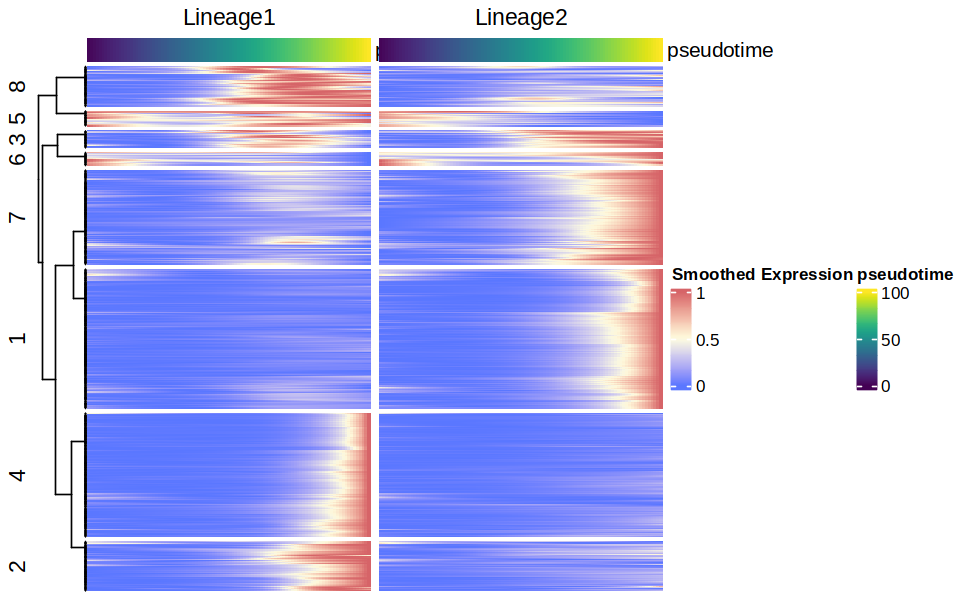

In [22]:
# Clustering
set.seed(42)
k = 8
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'Lineage1',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Lineage2',
                  show_column_names  = FALSE,
                  show_row_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)

options(repr.plot.height=5, repr.plot.width=8)
draw(hm_list)

### Plot heatmaps of Eomes & T ChIP signal surrounding differential peaks

In [23]:
chips = data.table(
    celltype = 'ChIP',
    genotype = '',
    path = c('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_dox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_dox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_EoGFP_nodox.bigwig',
            '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_bamCoverage_ChIP_BraGFP_nodox.bigwig'),
    name = c('Eomes ChIP', 'T ChIP', 'Eomes Ctrl', 'T Ctrl'),
    color = c('darkgreen', 'darkblue', 'grey90', 'grey95')
)
group.dt = as.data.table(group, keep.rownames = T) %>% setnames('rn', 'region')


In [24]:
input_region= rownames(WT)

order = input_region[unlist(row_order(hm_list))]

extend = 1000 # 1000
outlier = 0.98 # 0.95

gr <- GRanges(c(str_split(input_region, ":") %>% map_chr(1)), 
    IRanges(start = as.numeric(str_split(str_split(input_region, 
                        ":") %>% map_chr(2), "-") %>% map_chr(1)) - extend, 
            end = as.numeric(str_split(str_split(input_region, 
                      ":") %>% map_chr(2), "-") %>% map_chr(2)) +  extend), strand = "+")

gr

Warning message:
“The heatmap list has not been initialized. You might have different
results if you repeatedly execute this function, e.g. when
row_km/column_km was set. It is more suggested to do as `ht_list =
draw(ht_list); row_order(ht_list)`.”


GRanges object with 917 ranges and 0 metadata columns:
        seqnames              ranges strand
           <Rle>           <IRanges>  <Rle>
    [1]     chr1 133473120-133475720      +
    [2]    chr14     7849904-7852504      +
    [3]     chr6   32481384-32483984      +
    [4]    chr14   28500166-28502766      +
    [5]     chr9 111086113-111088713      +
    ...      ...                 ...    ...
  [913]     chr6   32482754-32485354      +
  [914]     chr1     5515143-5517743      +
  [915]     chr2 118528794-118531394      +
  [916]    chr15   93575487-93578087      +
  [917]     chr7 142668914-142671514      +
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

In [41]:
plot_bigwig = function(file, background = NULL, rollmean = NULL, outlier = 0.98){
    bigwig = mclapply(input_region, function(x){
        input_region = x
        gr <- GRanges(c(str_split(input_region, ":") %>% map_chr(1)), 
        IRanges(start = as.numeric(str_split(str_split(input_region, 
                            ":") %>% map_chr(2), "-") %>% map_chr(1)) - extend, 
                end = as.numeric(str_split(str_split(input_region, 
                          ":") %>% map_chr(2), "-") %>% map_chr(2)) +  extend), strand = "+")

        tmp = as.data.table(rtracklayer::import.bw(con = file, which = gr, as = "NumericList")) %>%
            .[, combine := ((.I - 1) %/% 10) + 1] %>%
            .[, .(mean_value = mean(value)), 
                  by = combine] %>%
            .[, pos := (combine-nrow(.)/2 ) * 10] %>%
            .[, region := x] 
        
        if(!is.null(rollmean)){
            tmp = tmp[, rollingmean := frollmean(mean_value, n = rollmean, align = "center")] %>%
                    .[, rollingmean := fifelse(is.na(rollingmean), mean_value, rollingmean)] %>% 
                .[,mean_value := rollingmean] %>% .[, rollingmean := NULL]
        }
        
        if(!is.null(background)){
            bg = as.data.table(rtracklayer::import.bw(con = background, which = gr, as = "NumericList")) %>%
                .[, combine := ((.I - 1) %/% 10) + 1] %>%
                .[, .(mean_value_bg = mean(value)), 
                      by = combine] %>%
                .[, pos := (combine-nrow(.)/2 ) * 10] %>%
                .[, region := x]
            if(!is.null(rollmean)){
                bg = bg[, rollingmean := frollmean(mean_value_bg, n = rollmean, align = "center")] %>%
                    .[, rollingmean := fifelse(is.na(rollingmean), mean_value_bg, rollingmean)] %>% 
                    .[,mean_value_bg := rollingmean] %>% .[, rollingmean := NULL]
            }
            tmp = merge(tmp, bg, by = c('region', 'pos')) %>%
                .[, mean_value := mean_value - mean_value_bg]
        }
        return(tmp)
    }, mc.cores = 40) %>%
        rbindlist()

    bigwig = merge(bigwig, group.dt, by = 'region')
    bigwig = bigwig[,group := factor(group, levels = c(8,5,3,6,7,1,4,2))]
    bigwig = bigwig[,region := factor(region, levels = order)]
    bigwig = bigwig %>%
        .[,value_no_outlier := ifelse(mean_value > quantile(mean_value, outlier, na.rm = T), quantile(mean_value, outlier, na.rm = T), mean_value)] %>% 
        .[,value_no_outlier := ifelse(value_no_outlier < quantile(value_no_outlier, 1-outlier, na.rm = T), quantile(value_no_outlier, 1-outlier, na.rm = T), value_no_outlier)]
    
    
    p = ggplot(bigwig, aes(pos, region, fill = minmax(value_no_outlier))) + 
        geom_tile() +
         viridis::scale_fill_viridis() +#limits = c(0, max(bigwig$value_no_outlier))) + 
        #scale_fill_gradientn(colors = rev(rainbow(4)), values = c(0, 0.2, 0.5, 1)) + 
        scale_x_continuous(expand = c(0,0)) + 
        scale_y_discrete(expand = c(0,0)) + 
        xlab('distance to centre (bp)') +
        facet_grid(group ~ ., scales = 'free_y', space = 'free_y') + 
        theme_bw() + 
        theme(axis.text = element_text(color = 'black'),
              axis.text.y = element_blank(),
              axis.title.y = element_blank(),
              axis.ticks.y = element_blank(),
              strip.background = element_blank(),
              strip.text = element_blank())
    return(p)
}

In [42]:
unique(group)

[1] 7 8 1 4 2 5 3 6

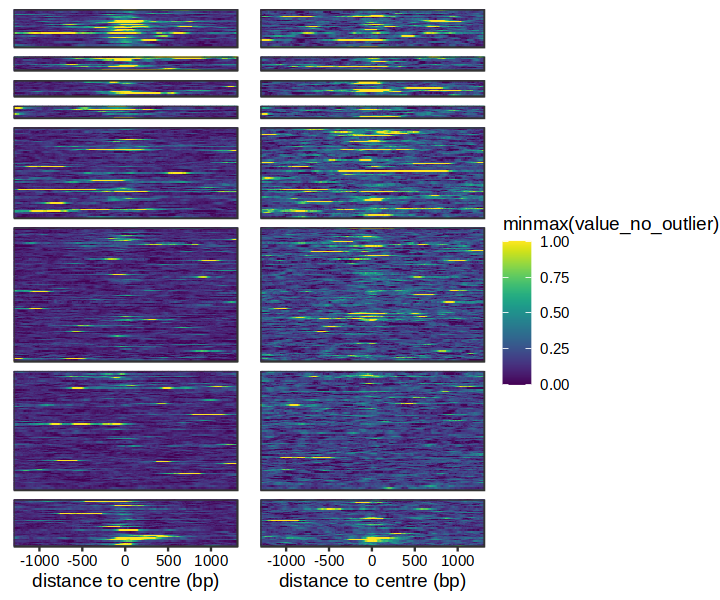

In [43]:
p1 = plot_bigwig(chips$path[1], chips$path[3])
p2 = plot_bigwig(chips$path[2], chips$path[4])
options(repr.plot.height=5, repr.plot.width=6)
ggarrange(p1, p2, common.legend = T, legend = 'right')

In [44]:
T_bed = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_Peaks_ChIP_BraGFP_pileup40.bed.gz') %>%
    setnames(c('chr', 'start','end', 'name'))
Eomes_bed = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/Eomes/GSE128466/GSE128466_Peaks_ChIP_EoGFP_pileup120.bed.gz') %>%
    setnames(c('chr', 'start','end', 'name'))

In [45]:
Eomes_gr = makeGRangesFromDataFrame(Eomes_bed)
T_gr = makeGRangesFromDataFrame(T_bed)

In [46]:
input_region= rownames(WT)
gr <- GRanges(c(str_split(input_region, ":") %>% map_chr(1)), 
    IRanges(start = as.numeric(str_split(str_split(input_region, 
                        ":") %>% map_chr(2), "-") %>% map_chr(1)), 
            end = as.numeric(str_split(str_split(input_region, 
                      ":") %>% map_chr(2), "-") %>% map_chr(2))), strand = "+")

gr

GRanges object with 917 ranges and 0 metadata columns:
        seqnames              ranges strand
           <Rle>           <IRanges>  <Rle>
    [1]     chr1 133474120-133474720      +
    [2]    chr14     7850904-7851504      +
    [3]     chr6   32482384-32482984      +
    [4]    chr14   28501166-28501766      +
    [5]     chr9 111087113-111087713      +
    ...      ...                 ...    ...
  [913]     chr6   32483754-32484354      +
  [914]     chr1     5516143-5516743      +
  [915]     chr2 118529794-118530394      +
  [916]    chr15   93576487-93577087      +
  [917]     chr7 142669914-142670514      +
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

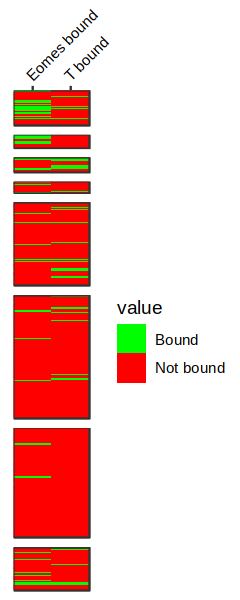

In [47]:
overlap = data.table(region = input_region) %>%
    .[, Eomes_bound := ifelse(.I %in% queryHits(findOverlaps(gr, Eomes_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>%
    .[, T_bound := ifelse(.I %in% queryHits(findOverlaps(gr, T_gr, type = 'any', minoverlap = 100)), 'Bound', 'Not bound')] %>% 
    melt(id.vars = 'region') %>%
    merge(., group.dt, by = 'region') %>% 
    .[,group := factor(group, levels = c(8,5,3,6,7,1,4,2))] %>% 
    .[,region := factor(region, levels = order)] %>%
    .[,variable := gsub('_', ' ', variable)]

options(repr.plot.height=5, repr.plot.width=2)
p3 = ggplot(overlap, aes(variable, region, fill = value)) + 
    geom_tile() + 
    facet_grid(group ~ ., scales = 'free_y', space = 'free_y') + 
   scale_fill_manual(values = c('Bound' = 'green', 'Not bound' = 'red')) + 
    scale_x_discrete(expand = c(0,0), position = 'top') + 
    scale_y_discrete(expand = c(0,0)) + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black'), 
          axis.text.y = element_blank(),
          axis.title.y = element_blank(),
          axis.title.x = element_blank(),
          axis.text.x = element_text(angle = 45, vjust = 0, hjust = 0),
          axis.ticks.y = element_blank(),
              strip.background = element_blank(),
              strip.text = element_blank())
p3

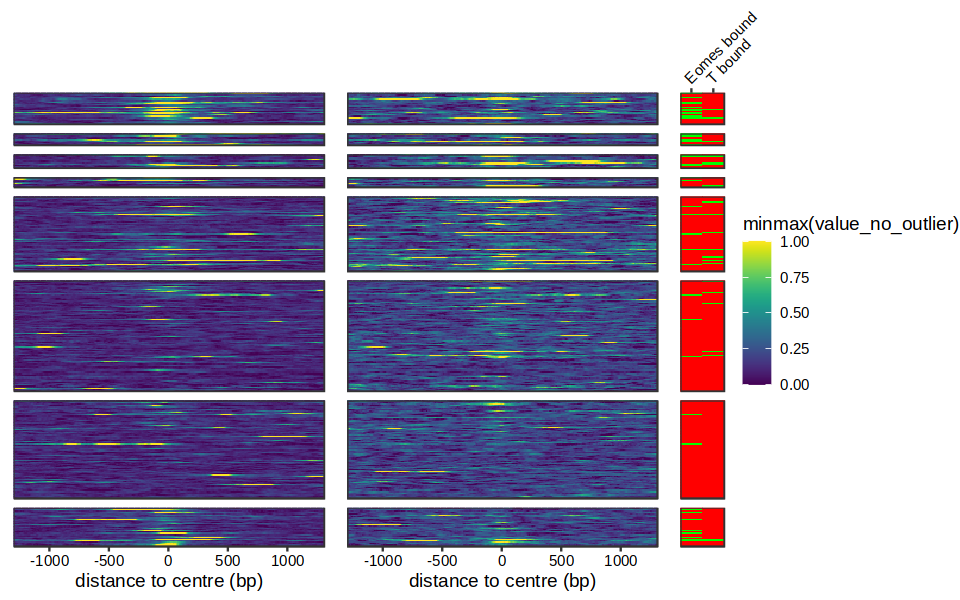

In [49]:
options(repr.plot.height=5, repr.plot.width=8)

ggarrange(p1, p2, p3, nrow = 1, widths = c(1,1,0.2), align = 'hv', common.legend = TRUE, legend = 'right')